<a href="https://colab.research.google.com/github/edgardlt03/ICO-Trabajos/blob/main/Participaci%C3%B3n_marzo_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

x, y = fetch_california_housing(return_X_y=True, as_frame=True)

x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.10, random_state=42
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.1111, random_state=42
)

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")

Train: 16512 | Val: 2064 | Test: 2064


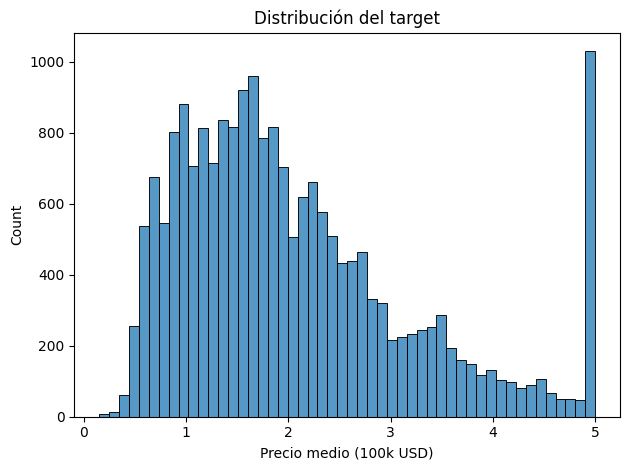

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y, bins=50)
plt.xlabel("Precio medio (100k USD)")
plt.title("Distribución del target")
plt.tight_layout()
plt.show()

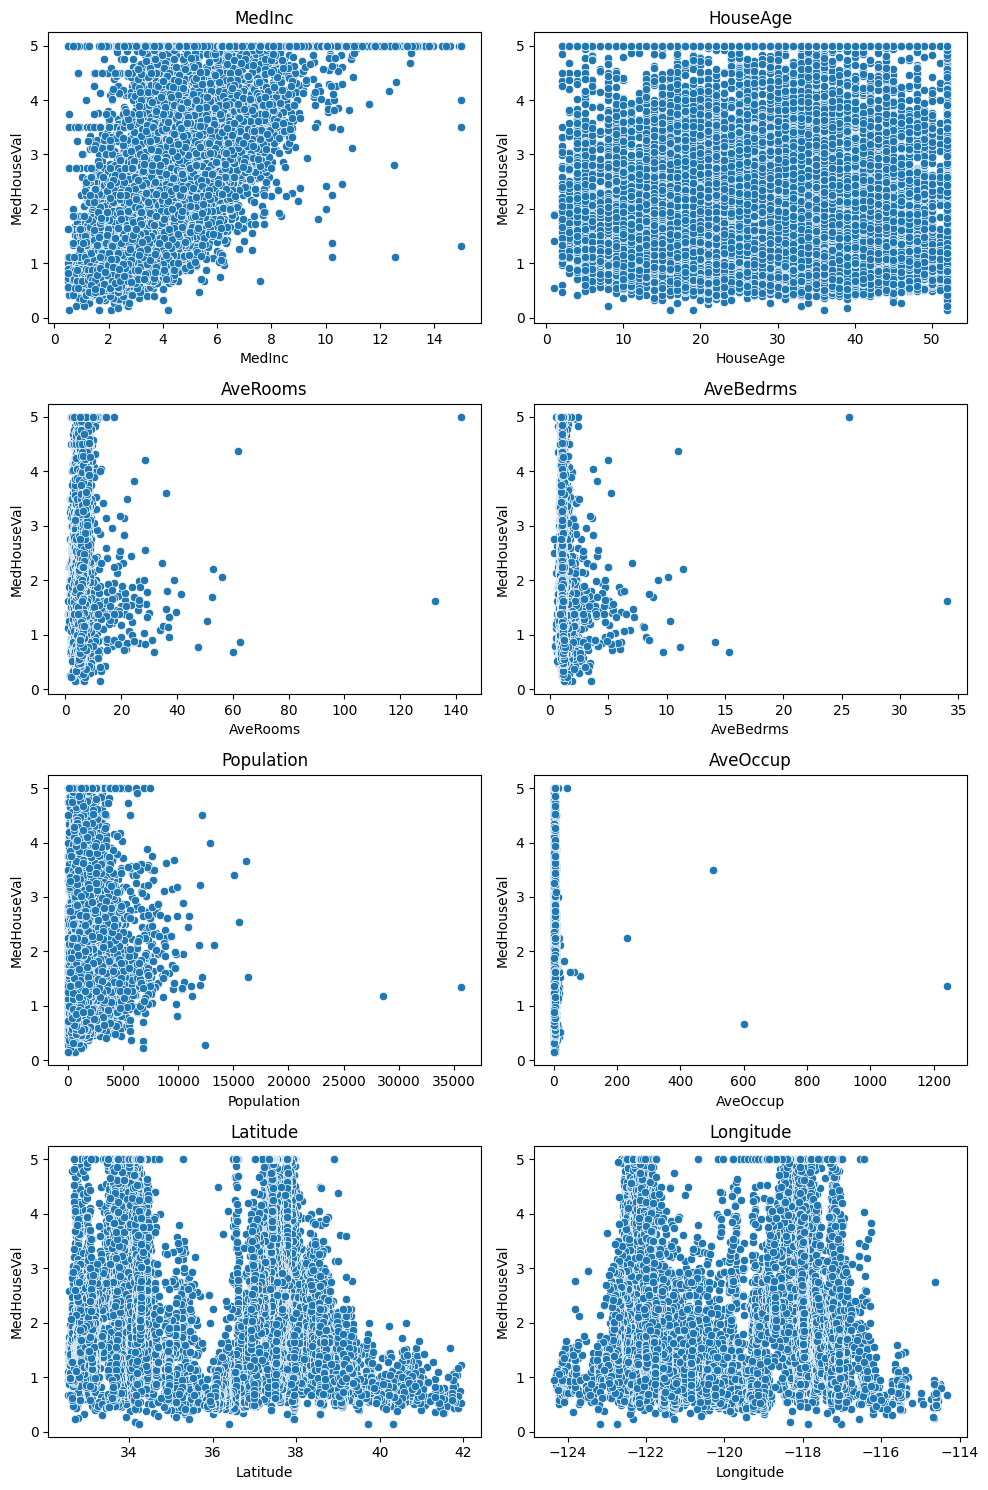

In [7]:
fig, axs = plt.subplots(4, 2, figsize=(10, 15))

for ax, col in zip(axs.ravel(), x.columns):
    sns.scatterplot(x=x[col], y=y, ax=ax)
    ax.set_title(col)

plt.tight_layout()

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

SCALE_COLS = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
GEO_COLS   = ['Latitude', 'Longitude']

class CaliforniaDataset(Dataset):
    def __init__(self, x, y):
        data      = torch.tensor(x.values, dtype=torch.float32)
        idx_scale = [x.columns.get_loc(c) for c in SCALE_COLS]
        idx_geo   = [x.columns.get_loc(c) for c in GEO_COLS]
        self.x_scale = data[:, idx_scale]
        self.x_geo   = data[:, idx_geo]
        self.y       = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.x_scale[idx], self.x_geo[idx]), self.y[idx]


train_dataset = CaliforniaDataset(x_train, y_train)
val_dataset   = CaliforniaDataset(x_val,   y_val)
test_dataset  = CaliforniaDataset(x_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256)
test_loader  = DataLoader(test_dataset,  batch_size=256)

In [8]:
import torch.nn as nn

class OutlierClipper(nn.Module):
    def __init__(self, x_train: torch.Tensor):
        super().__init__()
        q1  = torch.quantile(x_train, 0.25, dim=0)
        q3  = torch.quantile(x_train, 0.75, dim=0)
        iqr = q3 - q1
        self.register_buffer('lower', q1 - 1.5 * iqr)
        self.register_buffer('upper', q3 + 1.5 * iqr)

    def forward(self, x):
        return torch.clamp(x, min=self.lower, max=self.upper)


class ScalingLayer(nn.Module):
    def __init__(self, x_train: torch.Tensor):
        super().__init__()
        self.register_buffer('mean', x_train.mean(dim=0))
        self.register_buffer('std',  x_train.std(dim=0))

    def forward(self, x):
        return (x - self.mean) / (self.std + 1e-8)


class PreprocessingLayer(nn.Module):
    def __init__(self, x_train_scale: torch.Tensor):
        super().__init__()
        self.clipper = OutlierClipper(x_train_scale)
        clipped      = self.clipper(x_train_scale)
        self.scaler  = ScalingLayer(clipped)

    def forward(self, x_scale, x_geo):
        x_proc = self.scaler(self.clipper(x_scale))
        return torch.cat([x_proc, x_geo], dim=1)

In [10]:
INPUT_SIZE = len(SCALE_COLS) + len(GEO_COLS)  # 8

class CaliforniaModel(nn.Module):
    def __init__(self, hidden_sizes: list, dropout: float = 0.0):
        super().__init__()
        self.preprocessing = PreprocessingLayer(train_dataset.x_scale)

        layers  = []
        in_size = INPUT_SIZE
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))
            in_size = h
        layers.append(nn.Linear(in_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x_scale, x_geo):
        x = self.preprocessing(x_scale, x_geo)
        return self.network(x)

In [20]:
def train_model(model, train_loader, val_loader, n_epochs=50, lr=1e-3, weight_decay=0.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for (x_scale, x_geo), y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_scale, x_geo), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (x_scale, x_geo), y in val_loader:
                val_loss += criterion(model(x_scale, x_geo), y).item() * len(y)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    return history


def plot_learning_curves(history, title="Learning Curves"):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'],   label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_y = [], []
    with torch.no_grad():
        for (x_scale, x_geo), y in loader:
            all_preds.append(model(x_scale, x_geo))
            all_y.append(y)
    preds = torch.cat(all_preds)
    y     = torch.cat(all_y)
    mae   = torch.mean(torch.abs(preds - y)).item()
    mse   = torch.mean((preds - y) ** 2).item()
    rmse  = mse ** 0.5
    r2    = 1 - torch.sum((y - preds) ** 2).item() / torch.sum((y - y.mean()) ** 2).item()
    return {'MAE': round(mae, 6), 'MSE': round(mse, 6), 'R2': round(r2, 6), 'RMSE': round(rmse, 6)}

Epoch  10/50 | Train MSE: 0.5393 | Val MSE: 0.5590
Epoch  20/50 | Train MSE: 0.4524 | Val MSE: 0.4862
Epoch  30/50 | Train MSE: 0.4468 | Val MSE: 0.4933
Epoch  40/50 | Train MSE: 0.4291 | Val MSE: 0.4747
Epoch  50/50 | Train MSE: 0.4181 | Val MSE: 0.4689


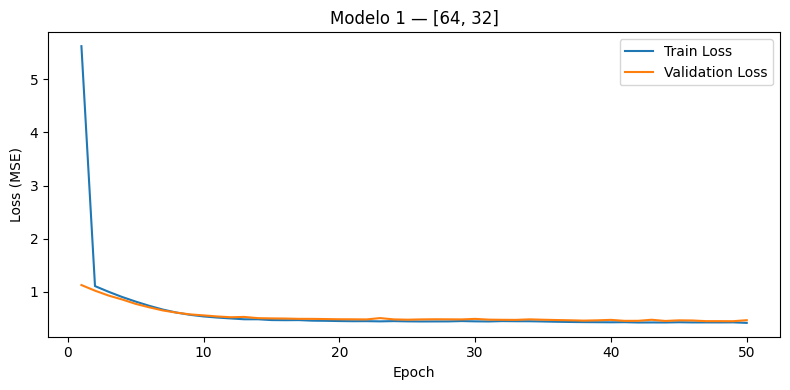

In [21]:
model1   = CaliforniaModel(hidden_sizes=[64, 32], dropout=0.0)
history1 = train_model(model1, train_loader, val_loader, n_epochs=50, lr=1e-3)

plot_learning_curves(history1, "Modelo 1 — [64, 32]")

Epoch  10/50 | Train MSE: 0.7218 | Val MSE: 0.9886
Epoch  20/50 | Train MSE: 0.5877 | Val MSE: 0.6311
Epoch  30/50 | Train MSE: 0.5346 | Val MSE: 0.5718
Epoch  40/50 | Train MSE: 0.5072 | Val MSE: 0.5539
Epoch  50/50 | Train MSE: 0.4912 | Val MSE: 0.5016


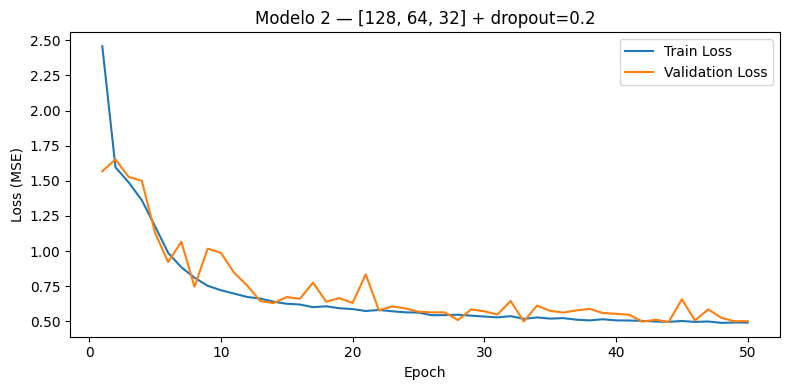

In [22]:
model2   = CaliforniaModel(hidden_sizes=[128, 64, 32], dropout=0.2)
history2 = train_model(model2, train_loader, val_loader, n_epochs=50, lr=1e-3)

plot_learning_curves(history2, "Modelo 2 — [128, 64, 32] + dropout=0.2")

Epoch  10/50 | Train MSE: 0.5111 | Val MSE: 0.5673
Epoch  20/50 | Train MSE: 0.4694 | Val MSE: 0.5253
Epoch  30/50 | Train MSE: 0.4497 | Val MSE: 0.4506
Epoch  40/50 | Train MSE: 0.4505 | Val MSE: 0.4410
Epoch  50/50 | Train MSE: 0.4388 | Val MSE: 0.4400


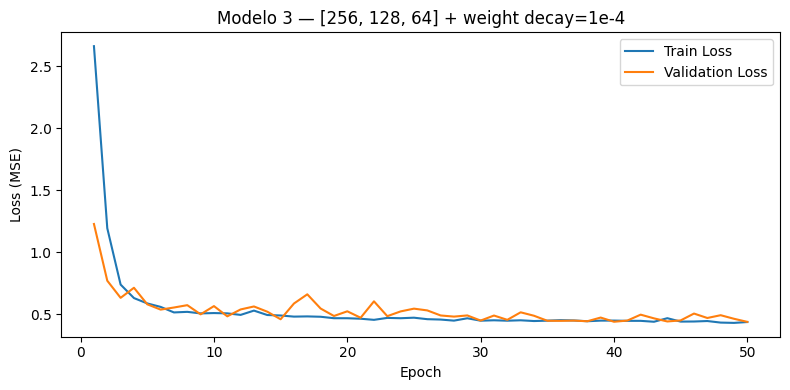

In [23]:
model3   = CaliforniaModel(hidden_sizes=[256, 128, 64], dropout=0.1)
history3 = train_model(model3, train_loader, val_loader, n_epochs=50, lr=3e-3, weight_decay=1e-4)

plot_learning_curves(history3, "Modelo 3 — [256, 128, 64] + weight decay=1e-4")

In [24]:
results = {
    'Modelo 1 [64,32]':      evaluate_model(model1, val_loader),
    'Modelo 2 [128,64,32]':  evaluate_model(model2, val_loader),
    'Modelo 3 [256,128,64]': evaluate_model(model3, val_loader),
}

names   = list(results.keys())
r2s     = [results[n]['R2']   for n in names]
rmses   = [results[n]['RMSE'] for n in names]
maes    = [results[n]['MAE']  for n in names]

for n in names:
    print(n, results[n])

Modelo 1 [64,32] {'MAE': 0.47489, 'MSE': 0.468891, 'R2': 0.633776, 'RMSE': 0.684756}
Modelo 2 [128,64,32] {'MAE': 0.493322, 'MSE': 0.50162, 'R2': 0.608214, 'RMSE': 0.708251}
Modelo 3 [256,128,64] {'MAE': 0.465077, 'MSE': 0.440037, 'R2': 0.656312, 'RMSE': 0.663353}
